

# Transfer Learning on E. coli to S. aureus

#### Mukundan Thanigaivelan, <thanigam@union.edu>

#### June 12, 2026

This notebook contains work on training Denoising Autoencoders on E. coli RNA-Seq data, and fine-tuning these models on S. aureus data to assess if transfer learning helps the model learn S. aureus pathways.

#### Outline

0. Before anything, we connect to the GitHub repository.
1. First we'll load classes from adage and modules for plotting, etc.
2. Next we'll take a look at the training data!
3. Train some models with hyperparameters from previous search.
4. Plot training loss over epochs.
5. Plot weight distributions of final models.

## 0. Connect to GitHub

In [1]:
!git clone https://github.com/Mukundan-T/seqADAGE.git

fatal: destination path 'seqADAGE' already exists and is not an empty directory.


In [2]:
%cd seqADAGE/Py/muk_transfer_learning

/content/seqADAGE/Py/muk_transfer_learning


In [3]:
!pip install -qq tensorflow keras statsmodels seaborn plotnine_prism pydeseq2

## 1. Loading classes & modules

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

In [6]:
# ADAGE
from adage import Adage as ad
from adage import SeqAdage

# Data Analysis
import pandas as pd
import numpy as np

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns
from plotnine import *
from plotnine_prism import *

# Miscellaneous
import time
import tensorflow as tf
from pydeseq2.preprocessing import deseq2_norm

In [7]:
# check CPU and GPU available in runtime
print("Num CPUs Available: ", len(tf.config.list_physical_devices('CPU')))
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))
print(tf.test.is_built_with_cuda())

Num CPUs Available:  1
Num GPUs Available:  1
True


## 2. Train models

In a previous hyperparameter seach I landed on the following:

* enccoding dimension: 459
* L1 normalizaion: 0
* L2 normalization: 0
* activation functios: tanh
* tied: True
* epochs: 50
* initialization: glorot_uniform
* batch_size: 15
* dropout: 0
* momentum: 0.6
* learning rate: 0.5

In [8]:
# Load filtered and re-normalized data
filename = '/content/drive/My Drive/Comp-Bio-Projs-S26/data/muk-in-use/ecmg_lcn01_medmean_normal_muk.csv'

filtered_df = pd.read_csv(filename, index_col = 0)
filtered_df.shape

(3608, 10233)

In [9]:
# Dict to store the models
comp = "ecmg_lcn01_medmean_normal_muk.csv"
model_dict_post = {}

# Timing how long training takes
stime = time.time()
ltime, c = 0, 0

# Random seed, maybe shouldn't be sequential
seeds = list(range(0,3))

# Loop through each random seed
for seed in seeds:
  name = f"ad_{comp}_2026_07_06_{seed+100}"
  print(name)
  ttime = time.time()

  sa = SeqAdage.SeqAdage(
    filename,
    seed = seed+100,
    enc_dim = 450,
    kl1 = 0,
    kl2 = 0,
    act = "tanh",
    act2 = "tanh",
    tied = True,
    epochs = 100,
    init = "glorot_uniform",
    batch_size = 15,
    dropout = 0,
    mm = 0.6,
    lr = 0.5
  )
  mseq = sa.train_model()
  temp = ad.Adage(sa.autoencoder, sa.history, sa.all_comp)

  model_dict_post[name] = temp
  ltime = ((time.time() - ttime) + ltime)
  c += 1

rtime = time.time() - stime

ad_ecmg_lcn01_medmean_normal_muk.csv_2026_07_06_100
Epoch 1/100
614/614 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.0206 - val_loss: 0.0179
Epoch 2/100
614/614 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0171 - val_loss: 0.0164
Epoch 3/100
614/614 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0161 - val_loss: 0.0157
Epoch 4/100
614/614 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0155 - val_loss: 0.0153
Epoch 5/100
614/614 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0152 - val_loss: 0.0150
Epoch 6/100
614/614 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0149 - val_loss: 0.0148
Epoch 7/100
614/614 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0147 - val_loss: 0.0146
Epoch 8/100
614/614 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0145 - val_loss: 0.0145
Epoch 9/100
614/614 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0143 - val_loss: 0.0144
Epoch 10/100
614/614 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0142 - val_loss: 0.0143
Epoch 11/100
614/614 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0141 - val_lo

In [10]:
# Time to run - statistics
print(rtime)
print(c)
print(ltime / c)
print(rtime / 60)

506.79409766197205
3
168.93111642201742
8.4465682943662


## 3. Plot training loss

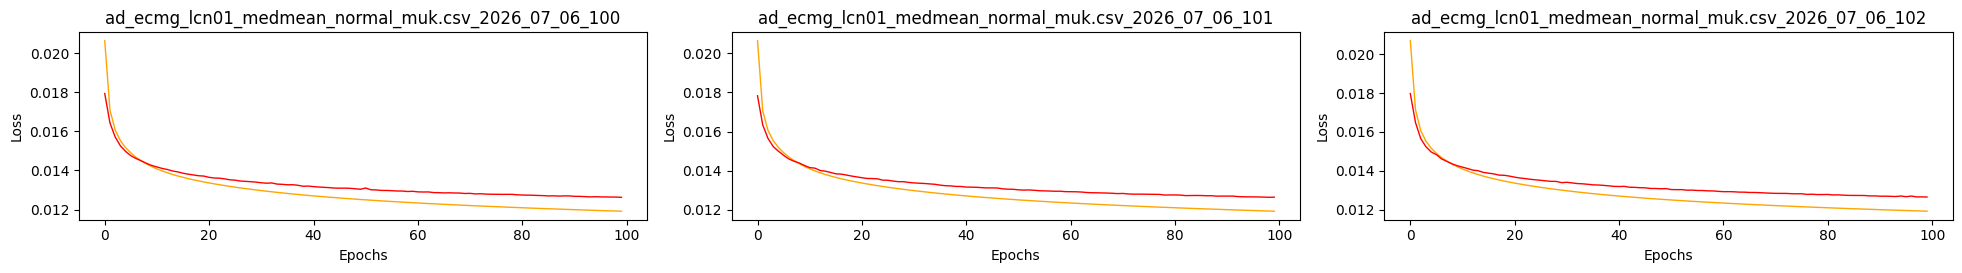

In [11]:
# Set layout for compendium and seeds
xd, yd = 1, len(seeds)

fig, ax = plt.subplots(xd, yd, figsize=(xd*20, yd))
fig.tight_layout(pad = 3.0)

# Plot each model in a facet
xi = 0

for seed in seeds:
  name = f"ad_{comp}_2026_07_06_{seed+100}"
  model_temp = model_dict_post[name]

  # Training loss (orange)
  ax[xi].plot(
    list(range(0,100)),
    model_temp.loss,
    linewidth = 1,
    markersize = 2,
    color = 'orange'
  )

  # CV loss (red)
  ax[xi].plot(
    list(range(0,100)),
    model_temp.val_loss,
    linewidth = 1,
    markersize = 2,
    color = 'red'
  )

  # Title
  ax[xi].set(title = name, xlabel = 'Epochs', ylabel = 'Loss')
  xi += 1

## 4. Plot weight distributions

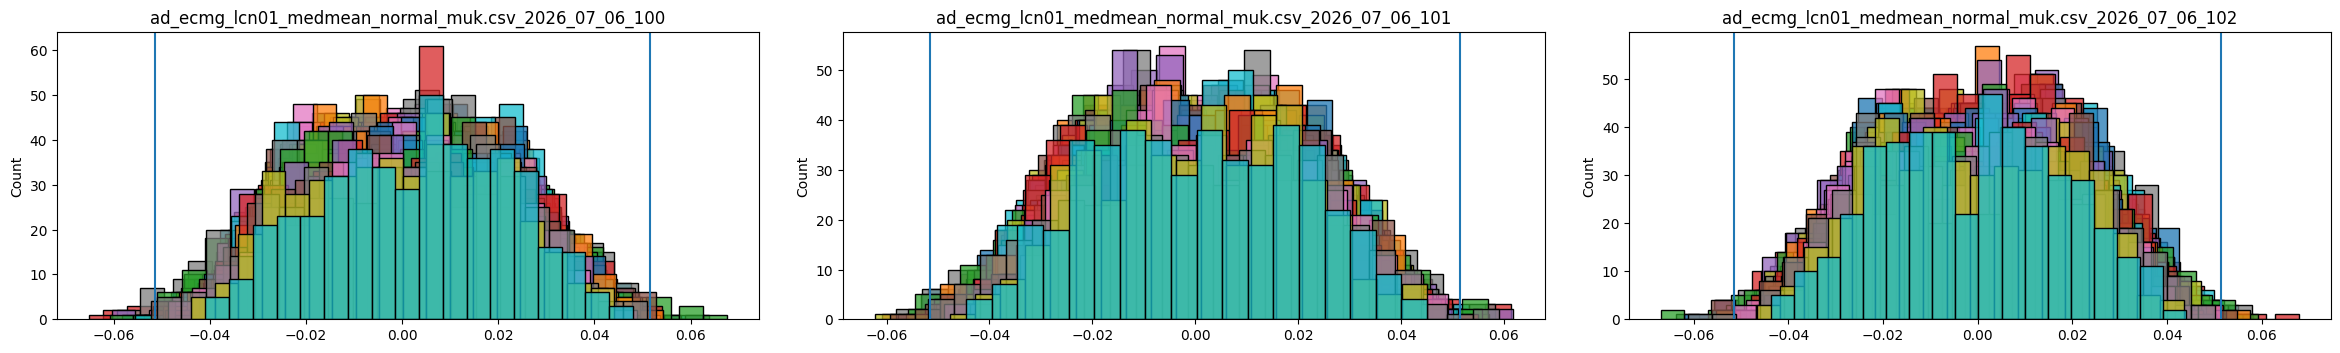

In [12]:
# Set layout for compendium and seeds
xd, yd = 1, len(seeds)
fig, ax = plt.subplots(xd, yd, figsize=(yd*8 , xd*4))
fig.tight_layout(pad = 3.0)

# Plot each model in a facet
xi = 0

for seed in seeds:
  name = f"ad_{comp}_2026_07_06_{seed+100}"
  model_temp = model_dict_post[name]

  # In each histogram:
  for node in range(0, 100):
    # Color each hidden node vector distribution
    sns.histplot(
      model_temp.weights[node],
      ax = ax[xi],
      binwidth = 0.005,
      kde = False
    )

  # Add markers for height/low weight cutoffs
  ax[xi].axvline(x = np.std(model_temp.weights)*2.5)
  ax[xi].axvline(x = np.std(model_temp.weights)*-2.5)
  ax[xi].set(title = name)
  xi += 1